<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 6 - Parameter Recovery </h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                Notebook author: <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

# Objective
The goal of this TD is to understand how to recover the parameters of a cognitive model from behavioral data. We will :
- Understand the steps to recover parameters from a model
- Implement a parameter recovery loop
- Visualize the results of the parameter recovery
- Build and visualize the confusion matrix



In [1]:
import pandas as pd
from IPython.core.pylabtools import figsize
from pybads import BADS, OptimizeResult
from tqdm import trange

from bandit_task import BanditTask, RestlessBanditTask
from tests import test_param_recovery_results
from matplotlib import pyplot as plt
import seaborn as sns
import scipy
import numpy as np

In [2]:
%reload_ext autoreload
%autoreload 2

## Define a task
We will start by instantiating a bandit task object that will be used to generate the data that we will use to recover the parameters of our model. The `RestlessBanditTask` class is already defined for you in the `bandit_task.py` file, and already imported in the cell above.

📝Instantiate a `RestlessBanditTask` with the following parameters **(no need to re-write the class!)**:
- initial mean of arm 0: `0.5`,
- initial mean of arm 1: `0.5`,
- standard deviation of the rewards: `0.20`,
- drift of the means: `0.15`,
- number of trials: `40`

Plot the task to visualize the evolution of the rewards over time.

⚠️ Make sure the task is not too easy. Since the generation process is stochastic, the trajectories can vary a lot. Make sure the reward trajectories of the two arms are intertwined, otherwise the task will be too easy and recovery will be poor. Relaunch the cell until you get a task that satisfies you.

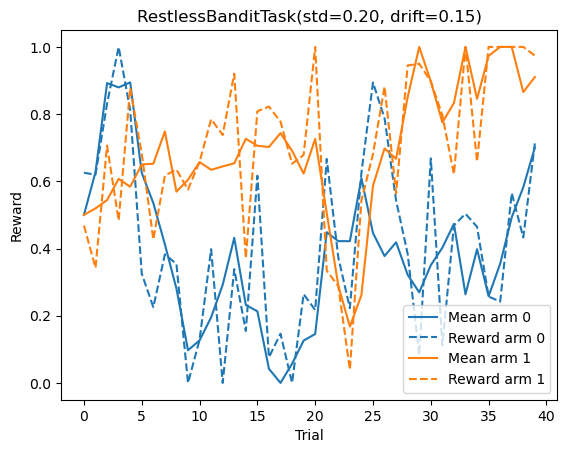

In [3]:
# Solution
task = RestlessBanditTask(0.5, 0.5, std=0.20, drift=0.15, n_trials=40)
task.plot()

## Update the RLModel class
We will reuse the `RLModel` class that was we wrote in TD 4 and 5. No need to re-write previous methods, they are already provided, but you should make sure that you understand what they do before you move forward, since you will need to use them:
- `policy()`
- `update()`
- `simulate()`
- `log_likelihood()`

Parameter recovery will require us to fit the `RLModel` many times to different behavioral datasets. Therefore, we need a compact and practical way to run the parameter estimation code. For this, we will use a new Python trick: **class methods**.

### Implement the `fit()` class method
Let's implement the `fit()` class method, that takes as inputs an array of **actions** and an array of **rewards**, and then return a new instance of the `RLModel` class, initialized with the parameters estimated (or fitted) on the provided behavioral data.

🔧*Technical note:* A **class method** is a method that we called from `RLModel` class itself, not from an instance. We will use it as an alternative constructor to create new instances of `RLModel` when we don't know what $\alpha$ and $\tau$ values to use and instead want to estimate them from behavioral data.

Here is an example of how you will use this class method to fit `RLModel` to behavioral data:
```python
rl_model = RLModel.fit(actions, rewards) # Call the class method to create a new instance
rl_model.simulate(task)    # Call its simulate method
```
To compare, here is how we used to instantiate `RLModel`s with specific parameter values:
```python
rl_model = RLModel(0.8, 0.1) # Call the constructor with values for alpha and tau
rl_model.simulate(task) # Call its simulate method
```

📝Implement the `fit()` method in the `RLModel` class. You can adapt the code that you wrote in the `fit_rl_model()` function in TD 5. If you didn't have time to do it, here are the instructions again:
 1. Write the `cost_function()`, that the optimizer needs to evaluate how bad is any combination of *learning rate* and _temperature_ to explain the data. In other words, it gives the "cost" associated with the parameter it receives as input. For this, you need to:
    -  Instantiate an RLModel with the parameters given as arguments (already done)
    -  Compute the log likelihood of the behavior inputted to the `fit()` classmethod, with the model instance you just created.
    -  The returned cost has to be something we wish to **minimize**, so you need to return the **negative log likelihood**.

2. Complete the settings of the BADS optimizer, each of which is a list with two values, one for each parameter in the following order: \[lr, temp]. I let you think about what settings could be appropriate, and we'll discuss it together. As a reference:
    - `x0` represent the typical value that you would expect for each parameter. It's the starting point of the optimization.
    - `lower_bounds` and `upper_bounds` specify the range of values that will be explored. In our case we have bounds of $[0, 1]$ for both parameters
    - `plausible_lower_bound` and `plausible_upper_bound` are more restrictive than the actual bounds and specify the range where we expect to find most solutions.

In [4]:
# Solution
class RLModel:
    def __init__(self, learning_rate: float, temperature: float):
        self.learning_rate = learning_rate
        self.temperature = temperature
        self.q_values = np.array([0.5, 0.5])

    def simulate(self, task):
        self.reset()
        actions = []
        probs = []
        rewards = []
        for trial_rewards in task:
            prob = self.policy()
            action = np.random.binomial(1, prob)
            reward = trial_rewards[action]
            self.update(action, reward)
            actions.append(action)
            probs.append(prob)
            rewards.append(reward)
        return np.array(actions, dtype=int), np.array(probs, dtype=float), np.array(rewards, dtype=float)

    def log_likelihood(self, actions: np.ndarray, rewards: np.ndarray) -> float:
        self.reset()
        loglikelihood = 0
        for action, reward in zip(actions, rewards):
            prob_a1 = self.policy()
            prob_chosen_action = prob_a1 if action == 1 else 1 - prob_a1
            prob_chosen_action = np.max([prob_chosen_action, 1e-6]) ## Little trick to avoid numerical errors
            loglikelihood += np.log(prob_chosen_action)
            self.update(action, reward)
        return loglikelihood

    def policy(self):
        np.seterr(over='ignore')  # Silence the warning for overflow
        prob = 1 / (1 + np.exp(-(self.q_values[1] - self.q_values[0]) / self.temperature))
        np.seterr(over='warn')
        return prob

    def update(self, action: int, reward: float):
        td_error = reward - self.q_values[action]
        self.q_values[action] += self.learning_rate * td_error

    def reset(self):
        self.q_values = np.array([0.5, 0.5])

    def __repr__(self):
        return f'RLModel(lr={self.learning_rate: .3f}, t={self.temperature: .3f})'

    @classmethod
    def fit(cls, actions: np.ndarray[int], rewards: np.ndarray[float], verbose: bool = True):
        def cost_function(params):
            model = cls(*params)
            log_likelihood = model.log_likelihood(actions, rewards)
            return -log_likelihood

        optimizer = BADS(
            fun=cost_function,
            x0=[0.5, 0.1],
            lower_bounds=[0, 0.001],
            upper_bounds=[1, 1],
            plausible_lower_bounds=[0.2, 0.01],
            plausible_upper_bounds=[0.9, 0.5],
            options={
                'display': 'iter' if verbose else 'off'
            }
        )
        result: OptimizeResult = optimizer.optimize()
        optimal_params: np.ndarray = result.x
        return cls(*optimal_params)

📝 Test your implementation manually:
- Instantiate an `RLModel` with parameters of your choice (we will name it `test_model`)
- Simulate the model on the task you previously created (under the variable `task`)
- Fit a new model to the generated behavior
- Fix the bugs 🪲

In [5]:
# Solution

# Create a test model
test_model = RLModel(0.1, 0.6)
# Generate a behavior trajectory
actions, _, rewards = test_model.simulate(task)
# Fit a new RLModel to the beahvior
fitted_model = RLModel.fit(actions, rewards)

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         86.3842               1                                 Uncertainty test
     0           6         41.9368               1         Initial mesh            Initial points
     0           9         35.9535               1       Successful poll           Train
     1          10         27.7268               1     Successful search (ES-ell)        
     1          19         27.7268             0.5         Refine grid             Train
     2          25         27.7268            0.25         Refine grid             Train
     3          26          27.726            0.25     Incremental search (ES-ell)        
     3          31          27.726           0.125         Refine grid             Train
     4          35         27.7259         

# Parameter recovery
## Let's start step by step

📝Instantiate an `RLModel` with parameters of your choice.
- Define the original parameters as a dictionary
- Instantiate the model with these parameters

*Python Note:* The `RLModel(**orig_params)` syntax unpacks the content of the `original_params` dictionary and passes each parameter name and value to the constructor of `RLModel`, as "keyword arguments".

In [6]:
# Solution
original_params = {
    'learning_rate': 0.1,
    'temperature': 0.1
}
original_model = RLModel(**original_params)

📝 Simulate a trajectory with this model and the task we defined at the beginning

In [7]:
# Solution
actions, _, rewards = original_model.simulate(task)

📝 Fit a new `RLModel` to the behavior that you just generated with your original model.

In [8]:
# Solution
recovered_model = RLModel.fit(actions, rewards)

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         18.9239               1                                 Uncertainty test
     0           6         14.8089               1         Initial mesh            Initial points
     0           9         14.8089             0.5         Refine grid             Train
     1          13         14.6294             0.5     Incremental search (ES-wcm)        
     1          17         14.6294            0.25         Refine grid             
     2          18         14.4921            0.25     Successful search (ES-wcm)        
     2          19         14.4555            0.25     Incremental search (ES-ell)        
     2          24         14.3115            0.25     Successful search (ES-ell)        
     2          29         14.1964           

📝Get the recovered parameters from the model you just fitted

In [9]:
# Solution
recovered_params = {
    'recov_learning_rate': recovered_model.learning_rate,
    'recov_temperature': recovered_model.temperature
}

📝Store the **original** and **recovered** parameters of your recovery in a pandas `Series`.

_Python Note_: `Series` are the data structures that Pandas uses to hold a **row** of data in a DataFrame. As opposed to a NumPy `array`, a `Series` has an **index** that can hold a distinct **label** to identify each element in the series. You can create a `Series` with a dictionary containing the data. Here you need to combine the content of the `original_parameters` dict and the `recovered_parameters` dict.

In [10]:
# Solution
single_result = pd.Series({**original_params, **recovered_params})
single_result

learning_rate          0.100000
temperature            0.100000
recov_learning_rate    0.007674
recov_temperature      0.010659
dtype: float64

Make sure your `single_result` Series contains the following items:
- learning_rate
- temperature
- recov_learning_rate
- recov_temperature

💭 Are your recovered parameter values close to the original ones? Try with a few different sets of original parameters to see if it seems to work better (or worse)!

## Parameter sampling
But wait, can we do better than choosing parameter values by hand?  
Sure! For that, we can define parameter distributions and sample from them. We can instantiate distributions from the `scipy.stats` library, and then sample from them by using their `.rvs()` method.

📝In the `param_distributions` dictionary, instantiate a `scipy.stats` distribution for each parameter of the model. You can have a look at the [scipy documentation](https://docs.scipy.org/doc/scipy/reference/stats.html):
- `learning_rate`: a uniform distribution between 0 and 1
- `temperature`: an exponential distribution with a scale of 0.1


In [11]:
# Solution
param_distributions = {
    'learning_rate': scipy.stats.uniform(0, 1),
    'temperature': scipy.stats.expon(scale=0.1)
}

👉Visualize the density of your parameter functions with the `display_distributions()` function below (just run the cell).

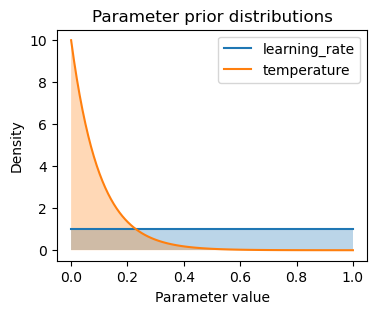

In [12]:
def display_distributions(distributions):
    plt.figure(figsize=(4,3))
    for param, distr in distributions.items():
        x = np.linspace(0, 1, 100)
        y = distr.pdf(x)
        plt.plot(x, y, label=param)
        plt.fill_between(x, 0, y, alpha=0.3)
    plt.legend()
    plt.xlabel('Parameter value')
    plt.ylabel('Density')
    plt.title('Parameter prior distributions')
    plt.show()

display_distributions(param_distributions)

## Full Parameter Recovery Loop
To recap, so far we have been able to:
- Define a bandit **task** and a **model** for which we want to evaluate parameter recovery
- Define **distributions** from which we can **sample** credible parameter values
- Write practical code to **simulate** behavior on the task using the model
- Write practical code to **recover** parameter estimates from the simulated behavior

Now let's put it all together!! 🚀

📝 Complete the `perform_parameter_recovery()` function, that takes the following inputs:
   - the `task` to evaluate (same as always)
   - the `ModelClass` to evaluate (we just pass `RLModel`)
   - the `parameter_distributions` defined just before
   - the number of loop cycles (sampling + simulation + recovery) to perform: `n_samplings`. It's better to set it to a small number (2) while we develop the code.

The function returns the results as a `DataFrame`, with as many rows as `n_samplings`.

In [13]:
# Solution
def perform_parameter_recovery(task, ModelClass, parameter_distributions, n_samplings):
    results = []
    for i in trange(n_samplings):
        # Sample parameters and instantiate original model
        original_params = {
            param_name: param_dist.rvs()
            for param_name, param_dist in parameter_distributions.items()
        }
        original_model = ModelClass(**original_params)

        # Simulate task with the original model
        actions, probs, rewards = original_model.simulate(task)

        # Fit the model to the simulated data and recover parameters
        recovered_model = ModelClass.fit(actions, rewards, verbose=False)

        recovered_params = {
            f"recovered_{param_name}": getattr(recovered_model, param_name)
            for param_name, param_dist in parameter_distributions.items()
        }

        # Store the results in a Pandas Series
        single_result = pd.Series({**original_params, **recovered_params})
        results.append(single_result)
    return pd.concat(results, axis=1).transpose()


dev_results = perform_parameter_recovery(task, RLModel, param_distributions, 2)
dev_results

100%|██████████| 2/2 [00:00<00:00,  2.17it/s]


,learning_rate,temperature,recovered_learning_rate,recovered_temperature
0,0.372706,0.074794,0.221269,0.029923
1,0.567401,0.009720,0.569141,0.001000


Test your `results` output DataFrame

In [14]:
test_param_recovery_results(dev_results)

✅ OK 👌


### Generate your parameter recovery data

⚙️ Once your recovery loop works correctly, you can increase the number of iterations and produce proper results. The number you choose will depend on your computer's power. Ideally you should aim for `n_samples` between 30 and 50, but if you see that it will take more than a few minutes, then decrease the number of samples.

💡 In your future projects, you will probably want to parallelize the loop iterations to speed this up by using all of your CPU's cores. For reference, a good library for this is [joblib](https://joblib.readthedocs.io/en/stable/).

In [15]:
n_samplings = 50    # Adjust this
results = perform_parameter_recovery(task, RLModel, param_distributions, n_samplings)

100%|██████████| 50/50 [00:25<00:00,  1.99it/s]


## Visualizing parameter recovery results

### Regression plot
#### Warm-up: learning rate only
Before writing a clean function to plot the results for all parameters, let's first focus on the **learning rate** and visualize how its close the recovered values are to the original ones.

📝 Make a regression plot that contains:
- A scatter plot showing the **original** learning rates on the **x axis**, against the **recovered** learning rate on the **y axis**
- A regression line
- A dashed identity line that indicates the ideal regression line
- Title and axis labels
- Make sure ranges are indentical on both axes

_Note_: You can have a look at the `regplot` function from the `Seaborn` library (see the [documentation](https://seaborn.pydata.org/generated/seaborn.regplot.html)).

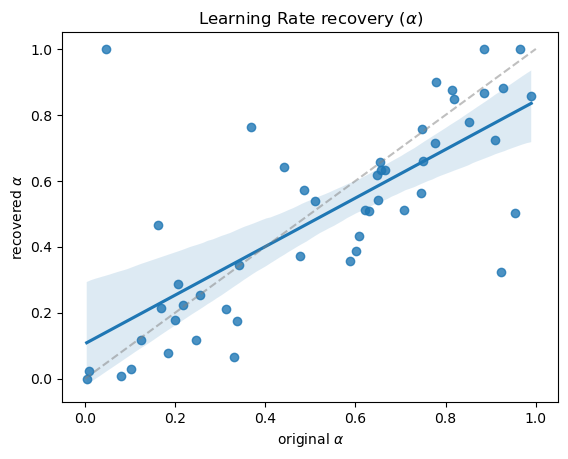

In [16]:
sns.regplot(data=results, x='learning_rate', y=f'recovered_learning_rate')
diag = np.linspace(0, 1, 100)
plt.plot(diag, diag, linestyle='--', color='grey', alpha=0.5)
plt.xlabel('original $\\alpha$')
plt.ylabel('recovered $\\alpha$')
plt.title('Learning Rate recovery ($\\alpha$)')
plt.show()

#### Display both parameters at once

Now we will encapsulate this code in a function that can take in a `results` DataFrame and produce a figure with as many subplots as parameters to recover.

_Technical Note_: To make a figure that contains many plots, you need to call the `plt.subplots(n_lines, n_columns)` method, which returns a `Figure` (`fig`) and an array of `Axes` (`axs`) (See the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).

The `Figure` object refers to the entire figure, and each `Axes` in the `axs` array contains a different scatter plot. Plotting on specific `Axes` requires a slightly different syntax then when we use `plt` with a signle plot. For example, if you want to create a sns.regplot in very first subplot (index 0), you will have to:
- Extract the corresponding `Axes` like this: `ax = axs[0]`
- Pass this `Axes` to the `ax` keyword argument of the `sns.regplot(..., ax=ax)` function to tell it to create the plot in that specific `Axes`
- Instead of calling `plt.plot()`, you then have to call `ax.plot()`
- Careful, the name of the methods change a bit:
    - `plt.title()` -> `ax.set_title()`
    - `plt.xlabel()` -> `ax.set_xlabel()`

🥺This part of Matplotlib is extremely confusing the first time you see it, so don't hesitate to ask for help if you need. But don't worry, it will be worth mastering this for your future research projects 😌.

📝Fill the `plot_results_scatter` function below

💪For those who are more advanced in Python, you can try to make the function more general by having it extract automatically the parameter names from the columns of the `results` DataFrame and determine the number of subplots accordignly. This will eventually be useful if you want to reuse this function for other models with different parameters.

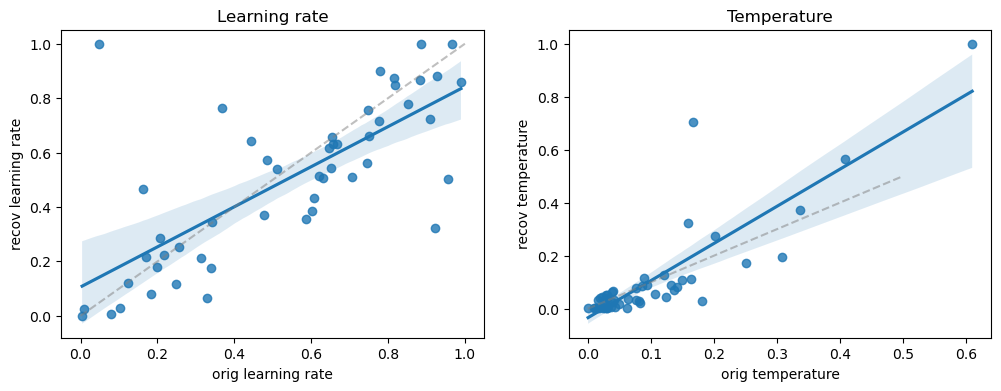

In [17]:
# Solution
def plot_results_scatter(results: pd.DataFrame):
    # Create a figure with 2 subplots (1 row and 2 columns)
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    ### Learning rate
    ax = axs[0]
    # Scatter plot for the learning rage
    sns.regplot(data=results, x='learning_rate', y=f'recovered_learning_rate', ax=ax)

    # Identity line
    diag = np.linspace(0, 1, 100)
    ax.plot(diag, diag, linestyle='--', color='grey', alpha=0.5)

    # Axis labels and title
    ax.set_xlabel('orig learning rate')
    ax.set_ylabel('recov learning rate')
    ax.set_title('Learning rate')


    ### Temperature
    ax = axs[1]
    # Scatter plot for the temperature
    sns.regplot(data=results, x='temperature', y=f'recovered_temperature', ax=ax)

    # Identity line
    diag = np.linspace(0, 0.5, 100)
    ax.plot(diag, diag, linestyle='--', color='grey', alpha=0.5)

    # Axis labels and title
    ax.set_xlabel('orig temperature')
    ax.set_ylabel('recov temperature')
    ax.set_title('Temperature')

    plt.show()

# Call your function
plot_results_scatter(results)

In [18]:
# Advanced solution (generic function)
def plot_results_scatter(result_df: pd.DataFrame):
    
    # Retrieve the names of the parameters in the result_df
    param_names = [param for param in result_df.columns if 'recovered' not in param]
    
    # Create a figure with as many subplots as parameters
    fig, axs = plt.subplots(1, len(param_names), figsize=(4 * len(param_names), 4))

    # Iterate through the parameter names and plot
    for i, param_name in enumerate(param_names):
        ax = axs[i]
        sns.regplot(x=param_name, y=f'recovered_{param_name}', data=result_df, ax=ax)

        # Diagonal
        x_min = result_df[[param_name, f"recovered_{param_name}"]].min().min()
        x_max = result_df[[param_name, f"recovered_{param_name}"]].max().max()
        diag = np.linspace(x_min, x_max, 100)
        ax.plot(diag, diag, linestyle='--', color='grey', alpha=0.5)

        # Labels and title
        ax.set_xlabel(param_name)
        ax.set_ylabel(f'recovered {param_name}')
        ax.set_title(param_name)

    plt.tight_layout()
    plt.show()

### Parameter confusion matrix
To make the confusion matrix, we have to proceed in steps:

📝1) Compute the correlation between all columns of your `results` DataFrame. For this, Pandas DataFrames have a `.corr()` method.

In [20]:
# Solution
all_correlations = results.corr()
all_correlations

,learning_rate,temperature,recovered_learning_rate,recovered_temperature
learning_rate,1.000000,0.053528,0.742045,-0.095622
temperature,0.053528,1.000000,0.046867,0.852002
recovered_learning_rate,0.742045,0.046867,1.000000,0.187511
recovered_temperature,-0.095622,0.852002,0.187511,1.000000


📝2) From you correlation matrix, extract the **columns** associated with the original parameter values and the **rows** associated with the recovered parameter values. 

This should give you the **parameter confusion matrix** (2x2)

In [21]:
# Solution
select_row_names = ['recovered_learning_rate', 'recovered_temperature']
select_column_names = ['learning_rate', 'temperature']
confusion_matrix = all_correlations.loc[select_row_names, select_column_names]
confusion_matrix

,learning_rate,temperature
recovered_learning_rate,0.742045,0.046867
recovered_temperature,-0.095622,0.852002


📝 3) Pack all of this in the `plot_results_confusion_matrix` function and add a heatmap visualization.

For the heatmap:
- You can use `seaborn.heatmap()`
- Add annotations with the correlation coefficients in the cells
- Use a colormap that is white at 0 and with a different color in the positive and negative values

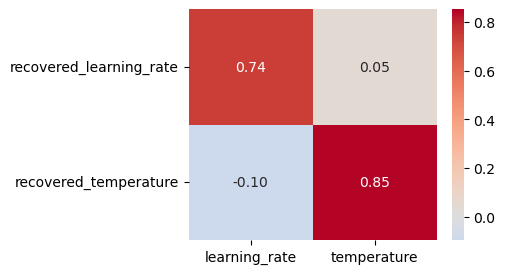

In [22]:
# Solution
def plot_results_confusion_matrix(result_df: pd.DataFrame):
    # Compute all correlations
    all_correlations = result_df.corr()

    # Compute the confusion matrix
    select_row_names = ['recovered_learning_rate', 'recovered_temperature']
    select_column_names = ['learning_rate', 'temperature']
    confusion_matrix = all_correlations.loc[select_row_names, select_column_names]

    # Produce a heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix, center=0, annot=True, fmt='.2f', cmap='coolwarm')
    plt.show()

plot_results_confusion_matrix(results)

In [30]:
# Advanced solution (generic, for an arbitrary number of parameters)
def plot_results_confusion_matrix(result_df: pd.DataFrame):
    param_names = [param for param in result_df.columns if 'recovered' not in param]
    recov_names = [f"recovered_{param}" for param in param_names]
    
    confusion_matrix = result_df.corr().loc[recov_names, param_names]
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix, center=0, annot=True, fmt='.2f', cmap='coolwarm')
    plt.show()

## Parameter recovery on an easy task
Let's now see how the recovery happens when the task is too easy.

📝 Instantiate a stationary `BanditTask` with:
- Means 0.8 and 0.2
- Standard deviation of 0.05
- 40 trials

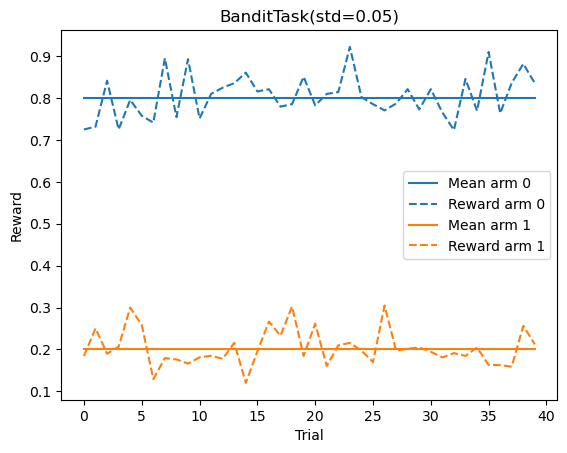

In [24]:
easy_task = BanditTask(0.8, 0.2, std=0.05, n_trials=40)
easy_task.plot()

📝 Run the parameter recovery and get the results as a DataFrame that you will name `easy_results`

In [25]:
easy_results = perform_parameter_recovery(easy_task, RLModel, param_distributions, n_samplings)

100%|██████████| 50/50 [00:25<00:00,  1.97it/s]


Plot the results (Scatter)

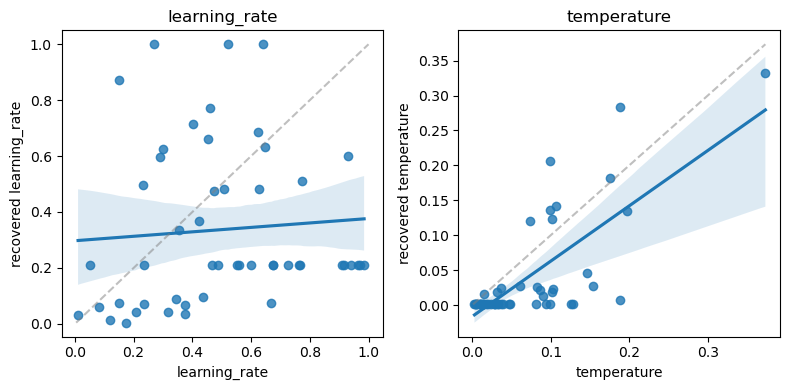

In [26]:
plot_results_scatter(easy_results)

📝Plot the confusion matrix

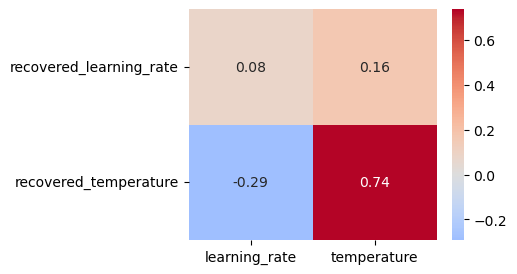

In [31]:
plot_results_confusion_matrix(easy_results)

💭 Can you explain the difference in recoverability between the two parameters?

### 💪 Optional: Histograms
If you have time, you can add a second row to your scatter visualization figure and add, under each scatter plot, a histogram of the differences between the original and recovered parameter values. This will allow you to assess the **bias** and **variance** of your parameter recovery.

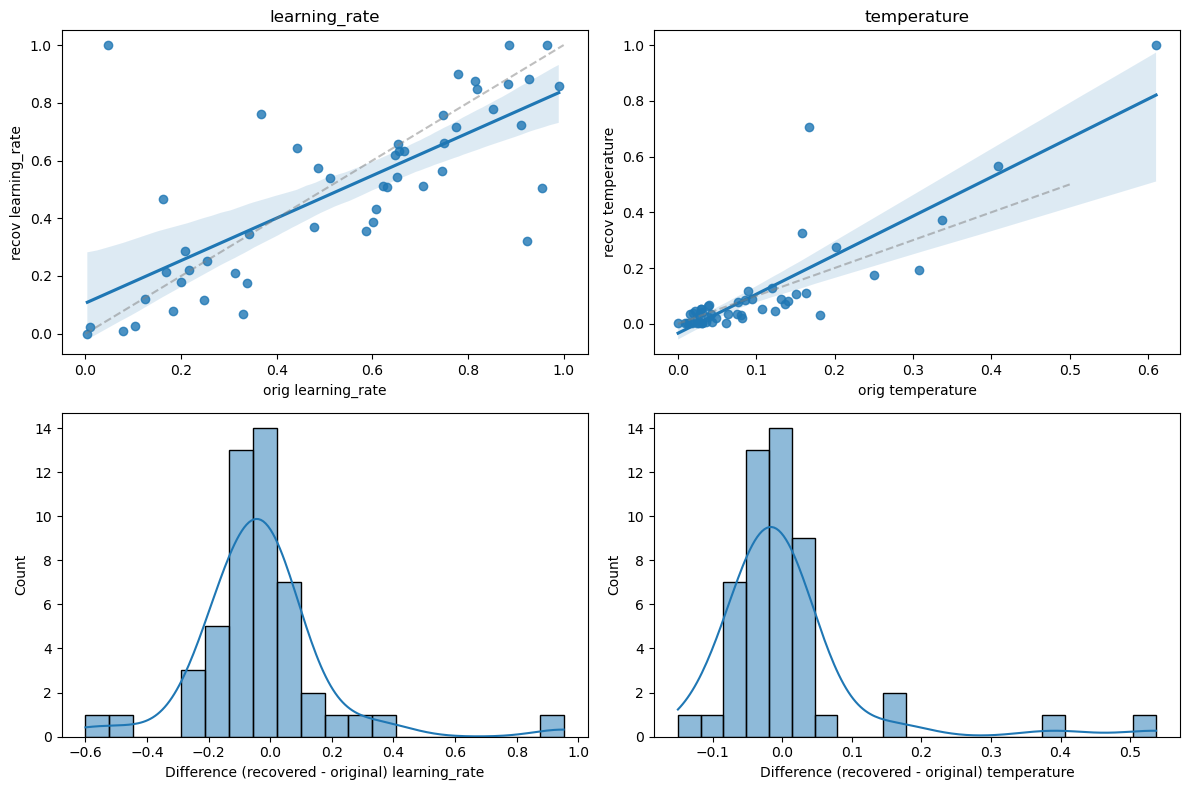

In [28]:
# Solution (with subfunctions to avoid code repetition)
def plot_results_scatter_and_hist(result_df: pd.DataFrame):

    # Helper functions to make the plots
    def make_scatter_plot(ax, param_name, low, high):
        sns.regplot(data=result_df, x=param_name, y=f"recovered_{param_name}", ax=ax)
        identity_values = np.linspace(low, high, 100)
        ax.plot(identity_values, identity_values, linestyle='--', color='grey', alpha=0.5)
        ax.set_xlabel(f"orig {param_name}")
        ax.set_ylabel(f"recov {param_name}")
        ax.set_title(param_name)

    def make_histogram(ax, param_name):
        difference = result_df[f"recovered_{param_name}"] - result_df[param_name]
        sns.histplot(data=difference, kde=True, ax=ax)
        ax.set_xlabel(f"Difference (recovered - original) {param_name}")


    # Create four subplots (2 rows and 2 columns)
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    ### Learning rate
    make_scatter_plot(axs[0,0], 'learning_rate', 0, 1)
    make_histogram(axs[1,0], 'learning_rate')

    ## Temperature
    make_scatter_plot(axs[0,1], 'temperature', 0, 0.5)
    make_histogram(axs[1,1], 'temperature')

    plt.tight_layout()
    plt.show()

plot_results_scatter_and_hist(results)

## 💪💪 Optional: Model with 3 parameters
If you want an extra challenge, you can extend the RLModel class to create a model with a third parameter, the **bias**. The bias represents a preference of the participant for arm 1, and is expresssed in the softmax policy. Refer to the class slides to find the equation and perform parameter recovery with this model.

Come and show me your implementation 😁